##### This notebook creates MTDNN-SE (pytorch) for classification prediction on Tox21, ClinTox, and RTECS

Using split data already saved.

Notebook shows results for seed = 124, but we also ran on seed 122, 123. 

Before use define desired pathways to save models,:
- path variable, in "Create checkpoint" section for models
- writer variable, in "Train the neural network model" section for tensorboard summary

In [3]:
# general and data handling
import numpy as np
import pandas as pd
import os
from collections import Counter

# Required RDKit modules
import rdkit as rd
from rdkit import DataStructs
from rdkit.Chem import AllChem

# modeling
import sklearn as sk
from sklearn.model_selection import train_test_split

# Graphing
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import time
import random
import joblib

In [5]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [6]:
import torch
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")  

In [7]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

In [8]:
# Ensure runs on GPU
import tensorflow as tf
import datetime, os

2026-01-30 11:12:51.527458: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 11:12:51.559678: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 11:12:51.772159: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 11:12:53.290009: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


##### Settings

In [9]:
# set seed value
seed_value = 124 #122 123 124, as used in MoleculeNet
torch.manual_seed(seed_value)
torch.cuda.manual_seed(seed_value)
np.random.seed(seed_value)
random.seed(seed_value)
torch.backends.cudnn.enabled=False
torch.backends.cudnn.deterministic=True

In [10]:
# number of bits for morgan fingerprints
morgan_bits = 4096

In [11]:
# number of radius for morgan fingerprints
morgan_radius = 2

In [12]:
train_epoch = 50 

In [13]:
batch = 512 

##### Load data

In [14]:
tox21_file  = '../../../../data/datasets/tox21/raw_data/tox21.csv'
tox21_tasks = ['NR-AR', 'NR-Aromatase', 'NR-PPAR-gamma', 'SR-HSE', 
               'NR-AR-LBD', 'NR-ER', 'SR-ARE', 'SR-MMP',
               'NR-AhR', 'NR-ER-LBD', 'SR-ATAD5', 'SR-p53']

tox21_data = pd.read_csv(tox21_file)
print('Reading {}... {} data loaded.'.format(tox21_file, len(tox21_data)))
tox21_data.head()

Reading ../../../../data/datasets/tox21/raw_data/tox21.csv... 8014 data loaded.


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,TOX3028,CC(O)(P(=O)(O)O)P(=O)(O)O


In [15]:
clintox_file = '../../../../data/datasets/clintox/raw_data/clintox.csv'
clintox_task = ['CT_TOX']

clintox_data = pd.read_csv(clintox_file)
print('Reading {}... {} data loaded.'.format(clintox_file, len(clintox_data)))
clintox_data.head(2)

Reading ../../../../data/datasets/clintox/raw_data/clintox.csv... 1491 data loaded.


,smiles,FDA_APPROVED,CT_TOX
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,1,0
1,[C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)C...,1,0


##### <font color = "blue"> Setting all tasks </font>

In [16]:
data = [tox21_data, clintox_data] 

In [17]:
all_tasks = tox21_tasks + clintox_task 

##### Load split data

In [18]:
# Load raw Tox21 and ClinTox data
tox21_raw = pd.read_csv(tox21_file)
clintox_raw = pd.read_csv(clintox_file)

# Create train/test split for Tox21 (80/20 split)
tox21_train, tox21_test = train_test_split(tox21_raw, test_size=0.2, random_state=seed_value)

# Further split test into test and valid (50/50 of the 20%)
tox21_valid, tox21_test = train_test_split(tox21_test, test_size=0.5, random_state=seed_value)

# Create train/test split for ClinTox (80/20 split)
clintox_train, clintox_test = train_test_split(clintox_raw, test_size=0.2, random_state=seed_value)

# Further split test into test and valid (50/50 of the 20%)
clintox_valid, clintox_test = train_test_split(clintox_test, test_size=0.5, random_state=seed_value)

# Merge Tox21 and ClinTox splits
train_data = tox21_train.merge(clintox_train, how='outer', on='smiles')
test_data = tox21_test.merge(clintox_test, how='outer', on='smiles')
valid_data = tox21_valid.merge(clintox_valid, how='outer', on='smiles')

data = [train_data, test_data, valid_data]

In [19]:
print("Total number of examples, train: " + str(data[0].shape[0]))
print("Total number of examples, test: " + str(data[1].shape[0]))
print("Total number of examples, valid: " + str(data[2].shape[0]))
print("Total number of examples, train+test+valid: " + str(data[0].shape[0] + data[1].shape[0] + data[2].shape[0]))

Total number of examples, train: 7592
Total number of examples, test: 951
Total number of examples, valid: 949
Total number of examples, train+test+valid: 9492


##### SMILES embedding featurization 

In [20]:
# Load existing SE featurization - dictionary of SMILES embedding given a SMILES
smiles_embed = torch.load("../../../../data/smiles_embedding/toxicity_smiles.pt")

/tmp/ipykernel_87572/1126325801.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  smiles_embed = torch.load("../../../../data/smiles_embedding/toxicity_smiles.pt")


In [21]:
# Obtain SMILES Embedding for given SMILES 
for i in range(len(data)):
    data[i]['smiles_embed'] = data[i]['smiles'].apply(lambda x: smiles_embed.get(x))

In [22]:
# Check if any NA 
sum = 0 
for i in range(len(data)):
    na = data[i]['smiles_embed'].isna().sum()
    sum = sum + na
print(sum)

0


##### Create train, test, valid sets

In [23]:
# replace NA with -1 -- used to deal with missing labels, 
#                       along with Binary Cross-Entropy loss
data[0] = data[0].fillna(-1)
data[1] = data[1].fillna(-1)
data[2] = data[2].fillna(-1)

In [24]:
train_data = data[0]
test_data  = data[1]
valid_data = data[2]

In [25]:
## Arrays for train / test / valid sets used for DNN 
# convert column with embedding to array
x_train = []
for tensor in train_data['smiles_embed']:
    x_train.append(tensor)

x_train = torch.stack(x_train)
x_train = x_train.numpy()

y_train = train_data[all_tasks].values

In [26]:
# convert column with embedding to array
x_test = []

for tensor in test_data['smiles_embed']:
    x_test.append(tensor)
x_test = torch.stack(x_test)
x_test = x_test.numpy()

y_test = test_data[all_tasks].values

In [27]:
# convert column with embedding to array
x_valid = []
for tensor in valid_data['smiles_embed']:
    x_valid.append(tensor)
x_valid = torch.stack(x_valid)
x_valid = x_valid.numpy()

    
y_valid = valid_data[all_tasks].values

In [28]:
# count the number of data points per class
N_train = np.sum(y_train >= 0, 0)
N_test  = np.sum(y_test >= 0, 0)
N_valid  = np.sum(y_valid >= 0, 0)

##### Deep Neural Network (pytorch)

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader

In [30]:
# convert data for pytorch
x_train_torch = x_train.astype(np.float32)
y_train_torch = y_train.astype(np.float32)

x_test_torch = x_test.astype(np.float32)
y_test_torch = y_test.astype(np.float32)

x_valid_torch = x_valid.astype(np.float32)
y_valid_torch = y_valid.astype(np.float32)

In [31]:
input_shape = x_train_torch.shape[1]
input_shape

128

In [32]:
# Class for MTDNN data
class MTDNNData(Dataset):

    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [33]:
training_set = MTDNNData(x_train_torch, y_train_torch)
training_generator = DataLoader(training_set, batch_size=batch, shuffle=True)

testing_set = MTDNNData(x_test_torch, y_test_torch)
testing_generator = DataLoader(testing_set, batch_size=len(testing_set), shuffle=False)

valid_set = MTDNNData(x_valid_torch, y_valid_torch)
valid_generator = DataLoader(valid_set, batch_size=len(valid_set), shuffle=False)

In [34]:
## MTDNN Model class
## Creates two shared layers for all tasks, and two separate layers for each task

class MTDNN(torch.nn.Module):
    def __init__(self, input_shape, all_tasks):
        super(MTDNN, self).__init__()

        # neural network layers
        self.shared_1 = torch.nn.Linear(input_shape, 2048)
        self.batchnorm_1 = torch.nn.BatchNorm1d(2048)
        
        self.shared_2 = torch.nn.Linear(2048, 1024)
        self.batchnorm_2 = torch.nn.BatchNorm1d(1024)
        
        self.hidden_3 = torch.nn.ModuleList([torch.nn.Linear(1024, 512) for task in all_tasks])
        self.batchnorm_3 = torch.nn.ModuleList([torch.nn.BatchNorm1d(512) for task in all_tasks])
        
        self.hidden_4 = torch.nn.ModuleList([torch.nn.Linear(512, 256) for task in all_tasks])
        self.batchnorm_4 = torch.nn.ModuleList([torch.nn.BatchNorm1d(256) for task in all_tasks])
        
        self.output   = torch.nn.ModuleList([torch.nn.Linear(256, 1) for task in all_tasks])
        
        # function for leaky ReLU
        self.leakyReLU = torch.nn.LeakyReLU(0.05)

    def forward(self, x):
        # shared layers
        x = self.shared_1(x)
        x = self.batchnorm_1(x)
        x = self.leakyReLU(x)
        
        x = self.shared_2(x)
        x = self.batchnorm_2(x)
        x = self.leakyReLU(x)
        
        x_task = [None for i in range(len(self.output))]  # initialize
        for task in range(len(self.output)):
            x_task[task] = self.hidden_3[task](x)
            x_task[task] = self.batchnorm_3[task](x_task[task])
            x_task[task] = self.leakyReLU(x_task[task])
            
            x_task[task] = self.hidden_4[task](x_task[task])
            x_task[task] = self.batchnorm_4[task](x_task[task])
            x_task[task] = self.leakyReLU(x_task[task])
            
            x_task[task] = self.output[task](x_task[task])
            x_task[task] = torch.sigmoid(x_task[task])
        
        y_pred = x_task
        
        return y_pred
    
model = MTDNN(input_shape, all_tasks).to(device)

###### Create checkpoint - saving and loading best model 

In [35]:
## Method from : https://gist.github.com/vsay01/45dfced69687077be53dbdd4987b6b17

import shutil
def save_ckp(state, is_best, checkpoint_path, best_model_path):
    """
    state: checkpoint we want to save
    is_best: is this the best checkpoint; min validation loss
    checkpoint_path: path to save checkpoint
    best_model_path: path to save best model
    """
    f_path = checkpoint_path
    # save checkpoint data to the path given, checkpoint_path
    torch.save(state, f_path)
    # if it is a best model, min validation loss
    if is_best:
        best_fpath = best_model_path
        # copy that checkpoint file to best path given, best_model_path
        shutil.copyfile(f_path, best_fpath)

In [36]:
def load_ckp(checkpoint_fpath, input_model, optimizer):
    """
    checkpoint_path: path to save checkpoint
    model: model that we want to load checkpoint parameters into       
    optimizer: optimizer we defined in previous training
    """
    # load check point
    checkpoint = torch.load(checkpoint_fpath)
    # initialize state_dict from checkpoint to model
    input_model.load_state_dict(checkpoint['state_dict'])
    # initialize optimizer from checkpoint to optimizer
    optimizer.load_state_dict(checkpoint['optimizer'])
    # initialize valid_loss_min from checkpoint to valid_loss_min
    train_loss_min = checkpoint['train_loss_min']
    # return model, optimizer, epoch value, min validation loss 
    return model, optimizer, checkpoint['epoch'], train_loss_min.item()

In [37]:
# Define and create the directory for saving models
path = 'trained_models/MTDNN_SE_clintox_tox21_seed124'
os.makedirs(path, exist_ok=True)
print(f"Directory '{path}' created/verified successfully")

Directory 'trained_models/MTDNN_SE_clintox_tox21_seed124' created/verified successfully


In [38]:
###### Pathways to save models 
checkpoint_path = path + '/current_checkpoint.pt'

#Path to saved model when train_epoch_loss <= train_loss_min
bestmodel_path = path + '/best_model.pt'  

#Path to saved model at minimum valid loss
bestmodel_byvalid = path + '/best_model_by_valid.pt' 

#Path to saved  when train_epoch_loss >= val_epoch_loss
bestmodel_byvalid_crossed = path + '/best_model_by_valid-crossed.pt'   

##### Train the neural network model

In [39]:
# Define the loss
criterion = torch.nn.BCELoss()

# Optimizers require the parameters to optimize and a learning rate
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [40]:
from torch.utils.tensorboard import SummaryWriter

# Define the desired pathway
writer = SummaryWriter('define-pathway/')

In [41]:
%%time
##################### With Tensorboard ######################
loss_history=[]  
correct_history=[]  
val_loss_history=[]  
val_correct_history=[] 
train_loss_min = np.Inf
val_loss_min = np.Inf


# Training
for e in range(train_epoch):
    
    model.train()
    # keep track of the loss over an epoch
    running_train_loss = 0
    running_valid_loss = 0
    running_train_correct = 0
    running_val_correct = 0
    y_train_true = []
    y_train_pred = []
    y_valid_true = []
    y_valid_pred = []
    batch = 0
    for x_batch, y_batch in training_generator:
        batch += 1
        if torch.cuda.is_available():
            x_batch, y_batch = x_batch.cuda(), y_batch.cuda() 
        
        # Forward pass: Compute predicted y by passing x to the model
        y_pred = model(x_batch)  # for all tasks
        
        # Compute loss over all tasks
        loss = 0
        correct = 0
        y_train_true_task = []
        y_train_pred_task = []
        for i in range(len(all_tasks)):
            y_batch_task = y_batch[:,i]
            y_pred_task  = y_pred[i][:,0] #check if predictions na
            
            # compute loss for labels that are not NA
            indice_valid = y_batch_task >= 0
            loss_task = criterion(y_pred_task[indice_valid], y_batch_task[indice_valid]) / N_train[i]
            
            loss += loss_task

            pred_train = np.round(y_pred_task[indice_valid].detach().cpu().numpy())
            target_train = y_batch_task[indice_valid].float()
            y_train_true.extend(target_train.tolist()) 
            y_train_pred.extend(pred_train.reshape(-1).tolist())

        # Zero gradients, perform a backward pass, and update the weights.
        writer.add_scalar("Accuracy/train", loss, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        # sum up the losses from each batch
        running_train_loss += loss.item()
        writer.add_scalar("Loss/train", running_train_loss, e)
        
    else:
        with torch.no_grad():    
        ## evaluation part 
            model.eval()
            for val_x_batch, val_y_batch in valid_generator:
                
                if torch.cuda.is_available():
                    val_x_batch, val_y_batch = val_x_batch.cuda(), val_y_batch.cuda() 
                
                val_output = model(val_x_batch)

                ## 2. loss calculation over all tasks 
                val_loss = 0
                val_correct = 0
                y_valid_true_task = []
                y_valid_pred_task = []
                for i in range(len(all_tasks)):
                    val_y_batch_task = val_y_batch[:,i]
                    val_output_task  = val_output[i][:,0]

                    # compute loss for labels that are not NA
                    indice_valid = val_y_batch_task >= 0
                    val_loss_task = criterion(val_output_task[indice_valid], val_y_batch_task[indice_valid]) / N_valid[i]

                    val_loss += val_loss_task
                    
                    pred_valid = np.round(val_output_task[indice_valid].detach().cpu().numpy())
                    target_valid = val_y_batch_task[indice_valid].float()
                    y_valid_true.extend(target_valid.tolist()) 
                    y_valid_pred.extend(pred_valid.reshape(-1).tolist())
                

                running_valid_loss+=val_loss.item()
                writer.add_scalar("Loss/valid", running_valid_loss, e)
        
        #epoch loss
        train_epoch_loss=np.mean(running_train_loss)
        val_epoch_loss=np.mean(running_valid_loss)  
       
        #epoch accuracy     
        train_epoch_acc = accuracy_score(y_train_true,y_train_pred)
        val_epoch_acc = accuracy_score(y_valid_true,y_valid_pred)
        
        #history
        loss_history.append(train_epoch_loss)  
        correct_history.append(train_epoch_acc)
        val_loss_history.append(val_epoch_loss)  
        val_correct_history.append(val_epoch_acc)  
        
        print("Epoch:", e, "Training Loss:", train_epoch_loss, "Valid Loss:", val_epoch_loss)
        print("Training Acc:", train_epoch_acc, "Valid Acc:", val_epoch_acc)
        
        # create checkpoint variable and add important data
        checkpoint = {
            'epoch': e + 1,
            'train_loss_min': train_epoch_loss,
            'val_loss_min': val_epoch_loss, 
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
        }
        
        # save checkpoint
        save_ckp(checkpoint, False, checkpoint_path, bestmodel_path)
        
        ## TODO: save the model if validation loss has decreased
        if train_epoch_loss <= train_loss_min:
            print('Training loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(train_loss_min,train_epoch_loss))
            # save checkpoint as best model
            save_ckp(checkpoint, True, checkpoint_path, bestmodel_path)
            train_loss_min = train_epoch_loss
            
        if train_epoch_loss >= val_epoch_loss:
            print('Training loss greater than validation loss ({:.6f} --> {:.6f}).  Saving model ...'.format(train_epoch_loss,val_epoch_loss))
            # save checkpoint as best model
            save_ckp(checkpoint, True, checkpoint_path, bestmodel_byvalid_crossed)
            train_loss_min = train_epoch_loss
            
        if val_epoch_loss <= val_loss_min:
            print('Validation loss decreased ({:.6f} --> {:.6f}). Saving model ...'.format(val_loss_min,val_epoch_loss))
            # save checkpoint as best model
            save_ckp(checkpoint, True, checkpoint_path, bestmodel_byvalid)
            val_loss_min = val_epoch_loss

Epoch: 0 Training Loss: 0.017372501839417964 Valid Loss: 0.008199077099561691
Training Acc: 0.8199283972716891 Valid Acc: 0.9078564500484966
Training loss decreased (inf --> 0.017373).  Saving model ...
Training loss greater than validation loss (0.017373 --> 0.008199).  Saving model ...
Validation loss decreased (inf --> 0.008199). Saving model ...
Epoch: 1 Training Loss: 0.007690897618886083 Valid Loss: 0.0050460780039429665
Training Acc: 0.93554211289775 Valid Acc: 0.9373181377303589
Training loss decreased (0.017373 --> 0.007691).  Saving model ...
Training loss greater than validation loss (0.007691 --> 0.005046).  Saving model ...
Validation loss decreased (0.008199 --> 0.005046). Saving model ...
Epoch: 2 Training Loss: 0.006036625272827223 Valid Loss: 0.004370349925011396
Training Acc: 0.9460973426746088 Valid Acc: 0.9392580019398642
Training loss decreased (0.007691 --> 0.006037).  Saving model ...
Training loss greater than validation loss (0.006037 --> 0.004370).  Saving mod

In [42]:
# Loads model at lowest validation loss 
loaded_model, optimizer, start_epoch, train_loss_min = load_ckp(bestmodel_byvalid, model, optimizer)

/tmp/ipykernel_87572/1156039392.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_fpath)


In [43]:
print("model = ", loaded_model)
print("optimizer = ", optimizer)
print("start_epoch = ", start_epoch)
print("train_loss_min = ", train_loss_min)
print("train_loss_min = {:.6f}".format(train_loss_min))

model =  MTDNN(
  (shared_1): Linear(in_features=128, out_features=2048, bias=True)
  (batchnorm_1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shared_2): Linear(in_features=2048, out_features=1024, bias=True)
  (batchnorm_2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (hidden_3): ModuleList(
    (0-12): 13 x Linear(in_features=1024, out_features=512, bias=True)
  )
  (batchnorm_3): ModuleList(
    (0-12): 13 x BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (hidden_4): ModuleList(
    (0-12): 13 x Linear(in_features=512, out_features=256, bias=True)
  )
  (batchnorm_4): ModuleList(
    (0-12): 13 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (output): ModuleList(
    (0-12): 13 x Linear(in_features=256, out_features=1, bias=True)
  )
  (leakyReLU): LeakyReLU(negative_slope=0.05)
)
optimizer =  Adam (
Parameter Group 0
    

##### Evaluate on test set 

In [44]:
# print test loss
for x_test_torch, y_test_torch in testing_generator:
    y_test_pred = loaded_model.eval().to(device).cpu()(x_test_torch)
    
    # Compute loss over all tasks
    loss = 0
    for i in range(len(all_tasks)):
        y_test_task = y_test_torch[:,i]
        y_pred_task  = y_test_pred[i][:,0]

        # compute loss for labels that are not NA
        indice_valid = y_test_task >= 0
        loss_task = criterion(y_pred_task[indice_valid], y_test_task[indice_valid]) / N_test[i]

        loss += loss_task
    
print(loss.item())

0.004353202413767576


Accuracy for MTDNN on Morgan Fingerprint: 0.9673469387755103
F1 for MTDNN on Morgan Fingerprint: 0.4782608695652174
 True Positive: 0.3235294117647059
 True Negative: 0.9985734664764622
False Positive: 0.0014265335235378032
False Negative: 0.6764705882352942
Test ROC AUC (NR-AR): 0.8110262649995803


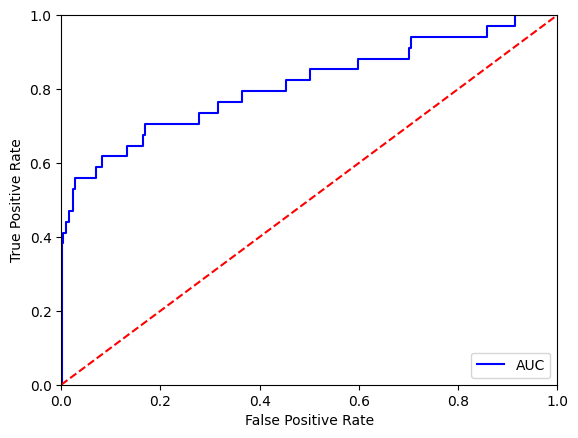

Accuracy for MTDNN on Morgan Fingerprint: 0.9452054794520548
F1 for MTDNN on Morgan Fingerprint: 0.36000000000000004
 True Positive: 0.24324324324324326
 True Negative: 0.9926873857404022
False Positive: 0.007312614259597806
False Negative: 0.7567567567567568
Test ROC AUC (NR-Aromatase): 0.8619497010721874


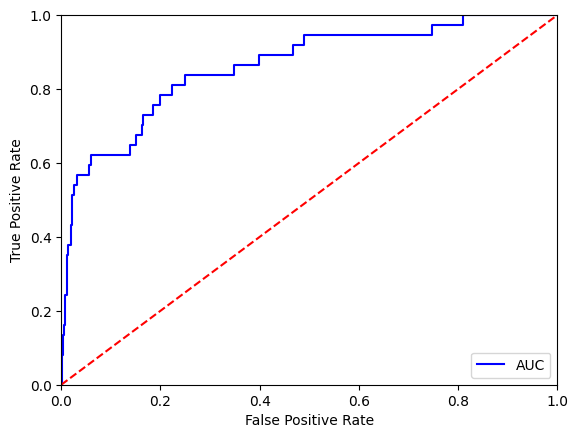

Accuracy for MTDNN on Morgan Fingerprint: 0.9722650231124808
F1 for MTDNN on Morgan Fingerprint: 0.1
 True Positive: 0.0625
 True Negative: 0.995260663507109
False Positive: 0.004739336492890996
False Negative: 0.9375
Test ROC AUC (NR-PPAR-gamma): 0.792259083728278


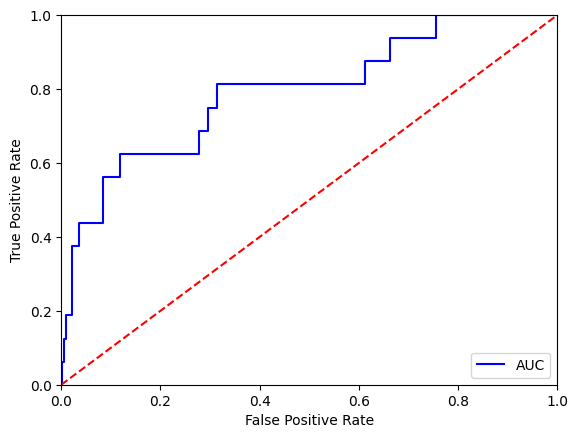

Accuracy for MTDNN on Morgan Fingerprint: 0.9464831804281345
F1 for MTDNN on Morgan Fingerprint: 0.2857142857142857
 True Positive: 0.175
 True Negative: 0.996742671009772
False Positive: 0.003257328990228013
False Negative: 0.825
Test ROC AUC (SR-HSE): 0.8061482084690554


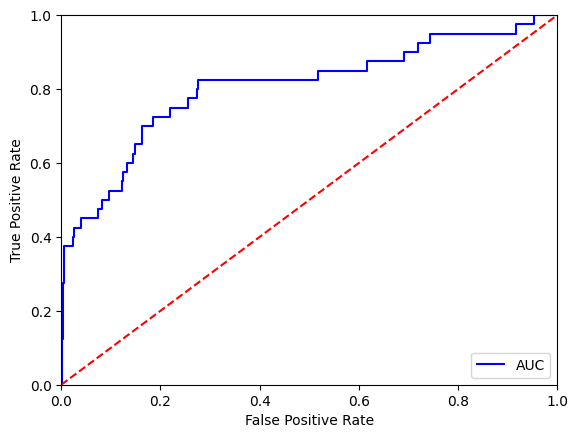

Accuracy for MTDNN on Morgan Fingerprint: 0.9751098096632503
F1 for MTDNN on Morgan Fingerprint: 0.5142857142857143
 True Positive: 0.391304347826087
 True Negative: 0.9954545454545455
False Positive: 0.004545454545454545
False Negative: 0.6086956521739131
Test ROC AUC (NR-AR-LBD): 0.9223978919631093


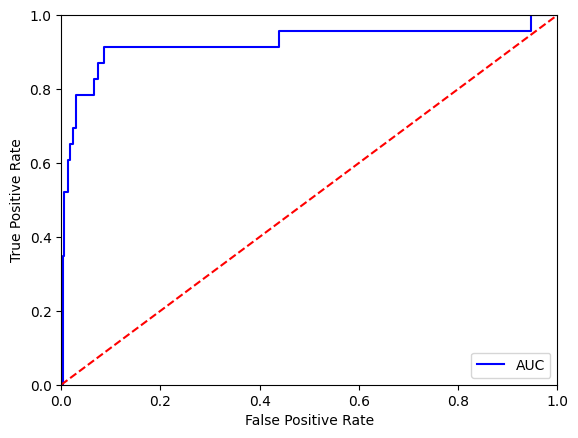

Accuracy for MTDNN on Morgan Fingerprint: 0.886435331230284
F1 for MTDNN on Morgan Fingerprint: 0.3571428571428571
 True Positive: 0.23255813953488372
 True Negative: 0.9890510948905109
False Positive: 0.010948905109489052
False Negative: 0.7674418604651163
Test ROC AUC (NR-ER): 0.6906297742318792


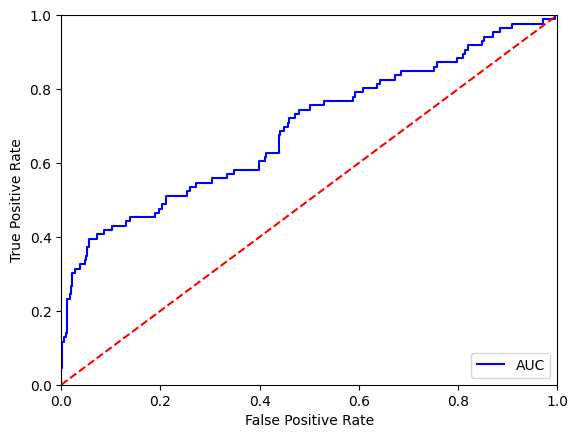

Accuracy for MTDNN on Morgan Fingerprint: 0.8697829716193656
F1 for MTDNN on Morgan Fingerprint: 0.4264705882352941
 True Positive: 0.32222222222222224
 True Negative: 0.9666011787819253
False Positive: 0.03339882121807466
False Negative: 0.6777777777777778
Test ROC AUC (SR-ARE): 0.8380048024448812


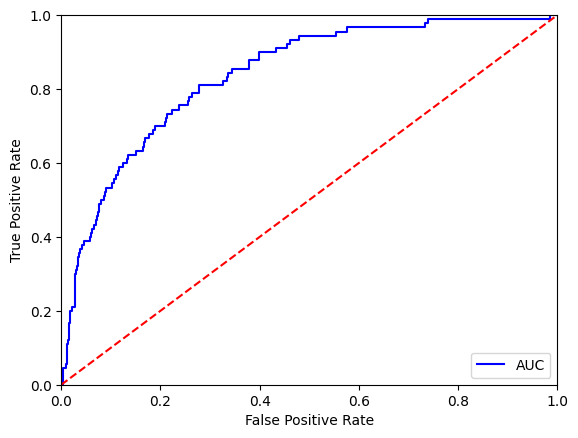

Accuracy for MTDNN on Morgan Fingerprint: 0.8833922261484098
F1 for MTDNN on Morgan Fingerprint: 0.576923076923077
 True Positive: 0.5
 True Negative: 0.9558823529411765
False Positive: 0.04411764705882353
False Negative: 0.5
Test ROC AUC (SR-MMP): 0.8827847805788982


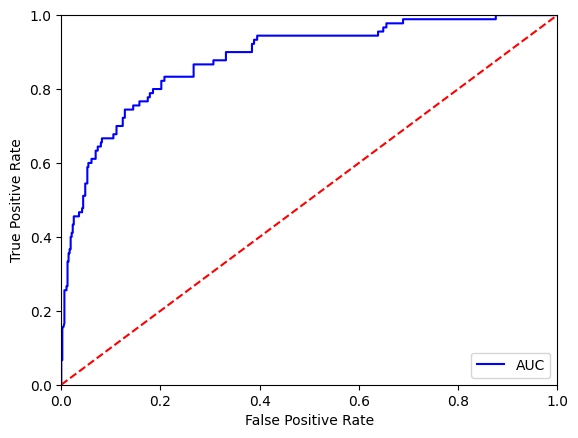

Accuracy for MTDNN on Morgan Fingerprint: 0.9077155824508321
F1 for MTDNN on Morgan Fingerprint: 0.5040650406504065
 True Positive: 0.43661971830985913
 True Negative: 0.964406779661017
False Positive: 0.03559322033898305
False Negative: 0.5633802816901409
Test ROC AUC (NR-AhR): 0.8357603246598233


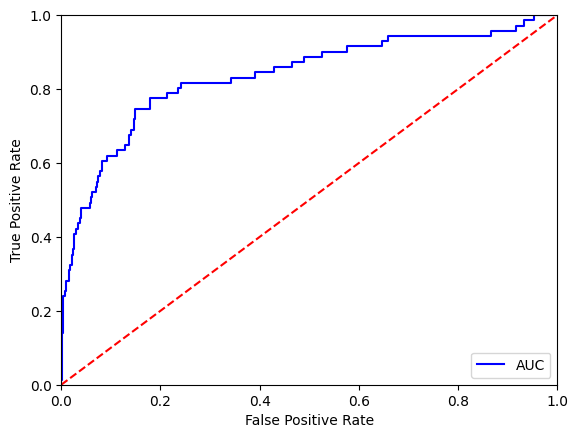

Accuracy for MTDNN on Morgan Fingerprint: 0.9545454545454546
F1 for MTDNN on Morgan Fingerprint: 0.40740740740740744
 True Positive: 0.3055555555555556
 True Negative: 0.9895209580838323
False Positive: 0.010479041916167664
False Negative: 0.6944444444444444
Test ROC AUC (NR-ER-LBD): 0.8671823020625417


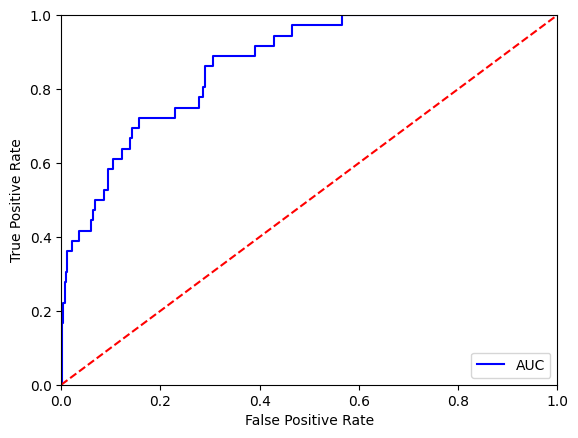

Accuracy for MTDNN on Morgan Fingerprint: 0.9594972067039106
F1 for MTDNN on Morgan Fingerprint: 0.2162162162162162
 True Positive: 0.13793103448275862
 True Negative: 0.9941775836972343
False Positive: 0.005822416302765648
False Negative: 0.8620689655172413
Test ROC AUC (SR-ATAD5): 0.8520303167193695


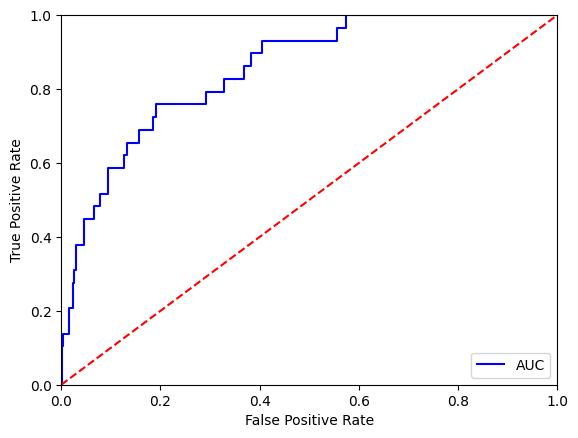

Accuracy for MTDNN on Morgan Fingerprint: 0.9470588235294117
F1 for MTDNN on Morgan Fingerprint: 0.41935483870967744
 True Positive: 0.325
 True Negative: 0.9859375
False Positive: 0.0140625
False Negative: 0.675
Test ROC AUC (SR-p53): 0.8123828125000001


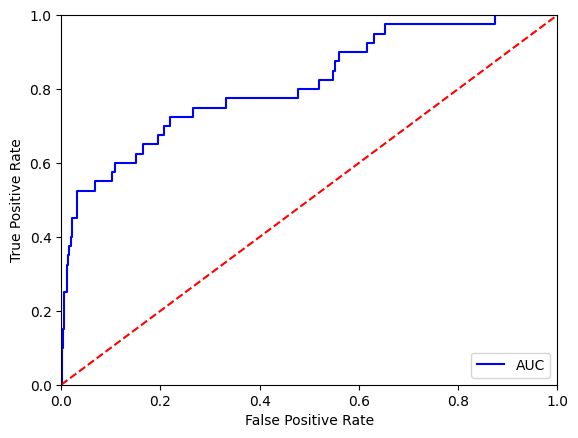

Accuracy for MTDNN on Morgan Fingerprint: 0.9733333333333334
F1 for MTDNN on Morgan Fingerprint: 0.8000000000000002
 True Positive: 0.8
 True Negative: 0.9857142857142858
False Positive: 0.014285714285714285
False Negative: 0.2
Test ROC AUC (CT_TOX): 0.96


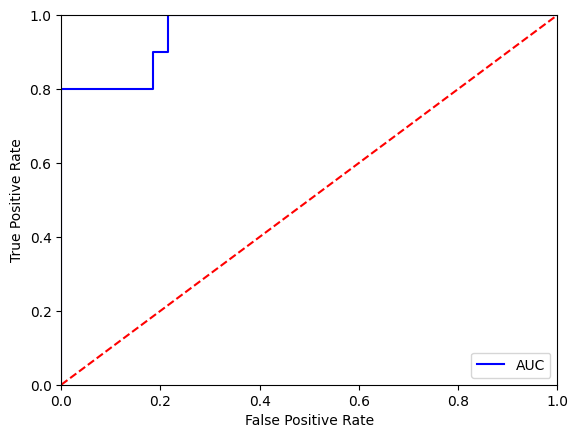

In [45]:
results = {}
# Collects performance metrics for all tasks on test set
for i in range(len(all_tasks)):
    
    valid_datapoints = y_test[:,i] >= 0
    y_test_task = y_test[valid_datapoints,i] 
    y_test_pred_task = y_test_pred[i].detach().numpy()[valid_datapoints,0]
    
    acc = accuracy_score(y_test_task, np.round(y_test_pred_task))
    print('Accuracy for MTDNN on Morgan Fingerprint:', acc)
    
    bacc = sk.metrics.balanced_accuracy_score(y_test_task, np.round(y_test_pred_task))

    f1 = f1_score(y_test_task, np.round(y_test_pred_task), pos_label=1)
    print('F1 for MTDNN on Morgan Fingerprint:', f1)

    cfm = sk.metrics.confusion_matrix(y_test_task, np.round(y_test_pred_task))
    cfm = cfm.astype('float') / cfm.sum(axis=1)[:, np.newaxis]
    
    tn, fp, fn, tp = cfm.ravel()
    pr = tp / (tp + fp)
    rc = tp / (tp + fn)
    print(' True Positive:', tp)
    print(' True Negative:', tn)
    print('False Positive:', fp)
    print('False Negative:', fn)
    
    
    auc = roc_auc_score(y_test_task, y_test_pred_task)
    print('Test ROC AUC ({}):'.format(all_tasks[i]), auc)
    
    results[all_tasks[i]] = [auc, acc, bacc, tn, tp, pr, rc, f1]

    fpr, tpr, threshold = sk.metrics.roc_curve(y_test_task, y_test_pred_task)
    plt.plot(fpr, tpr, 'b', label = 'AUC')
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [46]:
print('Task'.ljust(10), '\t', '  AUC ', ' ACC ', ' BACC ', ' TN  ', ' TP  ', ' PR  ', ' RC  ', ' F1  ')
for task, auc in results.items():
    print(task.ljust(10), '\t', np.round(auc,3))

Task       	   AUC   ACC   BACC   TN    TP    PR    RC    F1  
NR-AR      	 [0.811 0.967 0.661 0.999 0.324 0.996 0.324 0.478]
NR-Aromatase 	 [0.862 0.945 0.618 0.993 0.243 0.971 0.243 0.36 ]
NR-PPAR-gamma 	 [0.792 0.972 0.529 0.995 0.062 0.93  0.062 0.1  ]
SR-HSE     	 [0.806 0.946 0.586 0.997 0.175 0.982 0.175 0.286]
NR-AR-LBD  	 [0.922 0.975 0.693 0.995 0.391 0.989 0.391 0.514]
NR-ER      	 [0.691 0.886 0.611 0.989 0.233 0.955 0.233 0.357]
SR-ARE     	 [0.838 0.87  0.644 0.967 0.322 0.906 0.322 0.426]
SR-MMP     	 [0.883 0.883 0.728 0.956 0.5   0.919 0.5   0.577]
NR-AhR     	 [0.836 0.908 0.701 0.964 0.437 0.925 0.437 0.504]
NR-ER-LBD  	 [0.867 0.955 0.648 0.99  0.306 0.967 0.306 0.407]
SR-ATAD5   	 [0.852 0.959 0.566 0.994 0.138 0.959 0.138 0.216]
SR-p53     	 [0.812 0.947 0.655 0.986 0.325 0.959 0.325 0.419]
CT_TOX     	 [0.96  0.973 0.893 0.986 0.8   0.982 0.8   0.8  ]


##### See Valid set performance

In [47]:
# print test loss
for x_valid_torch, y_valid_torch in valid_generator:
    y_valid_pred = model.eval().to(device).cpu()(x_valid_torch)
    
    # Compute loss over all tasks
    loss = 0
    for i in range(len(all_tasks)):
        y_test_task = y_valid_torch[:,i]
        y_pred_task  = y_valid_pred[i][:,0]

        # compute loss for labels that are not NA
        indice_valid = y_test_task >= 0
        loss_task = criterion(y_pred_task[indice_valid], y_test_task[indice_valid]) / N_test[i]

        loss += loss_task
    
print(loss.item())

0.004463115707039833


Accuracy for deepnn on Morgan Fingerprint: 0.9750656167979003
F1 for deepnn on Morgan Fingerprint: 0.5128205128205129
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.9986376  0.0013624 ]
 [0.64285714 0.35714286]]
 True Positive: 0.35714285714285715
 True Negative: 0.9986376021798365
False Positive: 0.0013623978201634877
False Negative: 0.6428571428571429
Test ROC AUC (NR-AR): 0.7545737641105488


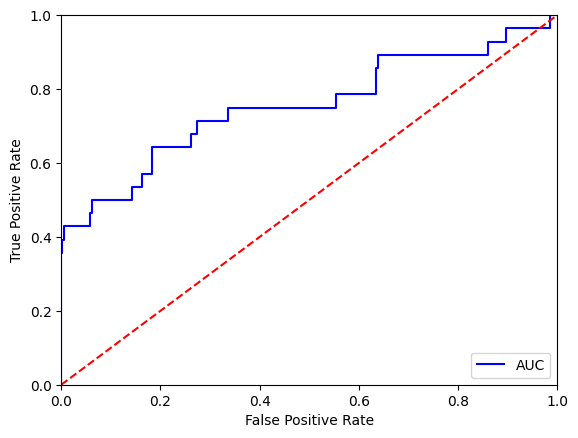

Accuracy for deepnn on Morgan Fingerprint: 0.964824120603015
F1 for deepnn on Morgan Fingerprint: 0.36363636363636365
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.98958333 0.01041667]
 [0.71428571 0.28571429]]
 True Positive: 0.2857142857142857
 True Negative: 0.9895833333333334
False Positive: 0.010416666666666666
False Negative: 0.7142857142857143
Test ROC AUC (NR-Aromatase): 0.935433201058201


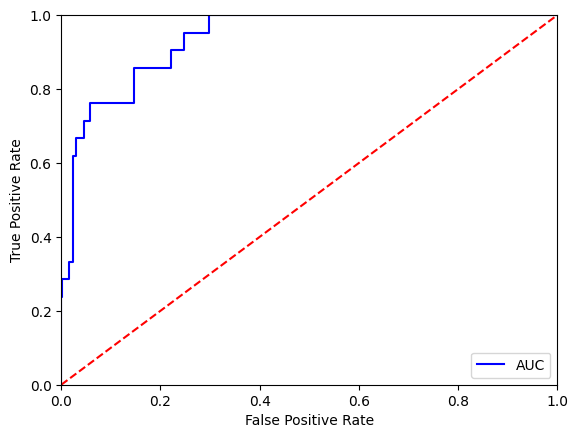

Accuracy for deepnn on Morgan Fingerprint: 0.9625187406296851
F1 for deepnn on Morgan Fingerprint: 0.0
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.99689441 0.00310559]
 [1.         0.        ]]
 True Positive: 0.0
 True Negative: 0.9968944099378882
False Positive: 0.003105590062111801
False Negative: 1.0
Test ROC AUC (NR-PPAR-gamma): 0.8799621928166351


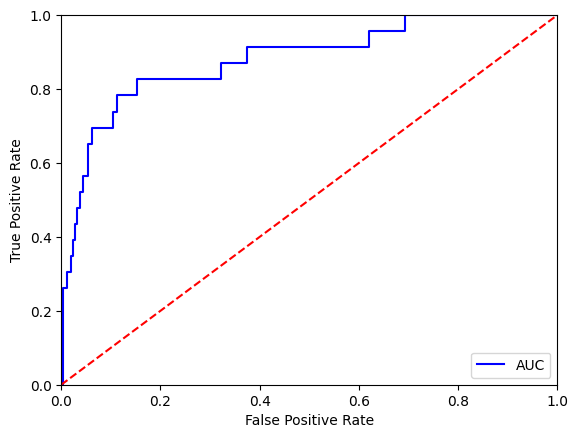

Accuracy for deepnn on Morgan Fingerprint: 0.947209653092006
F1 for deepnn on Morgan Fingerprint: 0.2222222222222222
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.99839744 0.00160256]
 [0.87179487 0.12820513]]
 True Positive: 0.1282051282051282
 True Negative: 0.9983974358974359
False Positive: 0.0016025641025641025
False Negative: 0.8717948717948718
Test ROC AUC (SR-HSE): 0.859344181459566


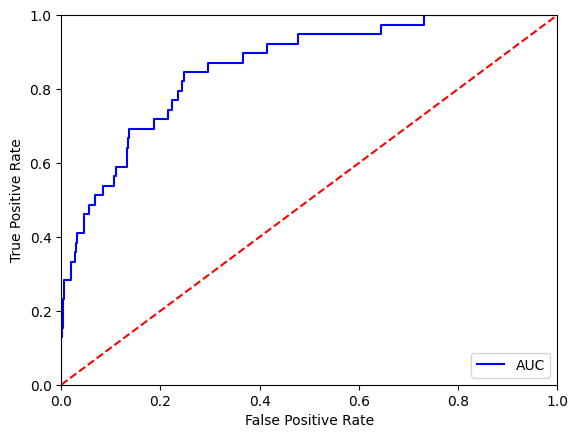

Accuracy for deepnn on Morgan Fingerprint: 0.9756795422031473
F1 for deepnn on Morgan Fingerprint: 0.48484848484848486
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.99704142 0.00295858]
 [0.65217391 0.34782609]]
 True Positive: 0.34782608695652173
 True Negative: 0.9970414201183432
False Positive: 0.0029585798816568047
False Negative: 0.6521739130434783
Test ROC AUC (NR-AR-LBD): 0.9114998713660921


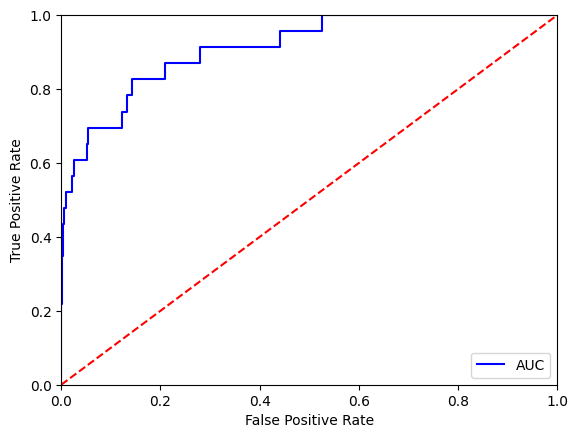

Accuracy for deepnn on Morgan Fingerprint: 0.9029275808936826
F1 for deepnn on Morgan Fingerprint: 0.39999999999999997
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.98949212 0.01050788]
 [0.73076923 0.26923077]]
 True Positive: 0.2692307692307692
 True Negative: 0.989492119089317
False Positive: 0.010507880910683012
False Negative: 0.7307692307692307
Test ROC AUC (NR-ER): 0.766974269163411


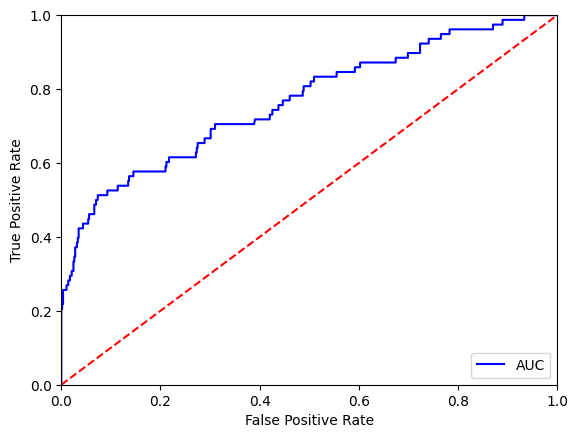

Accuracy for deepnn on Morgan Fingerprint: 0.8631051752921536
F1 for deepnn on Morgan Fingerprint: 0.43835616438356156
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.96806387 0.03193613]
 [0.67346939 0.32653061]]
 True Positive: 0.32653061224489793
 True Negative: 0.9680638722554891
False Positive: 0.031936127744510975
False Negative: 0.673469387755102
Test ROC AUC (SR-ARE): 0.8565012831479897


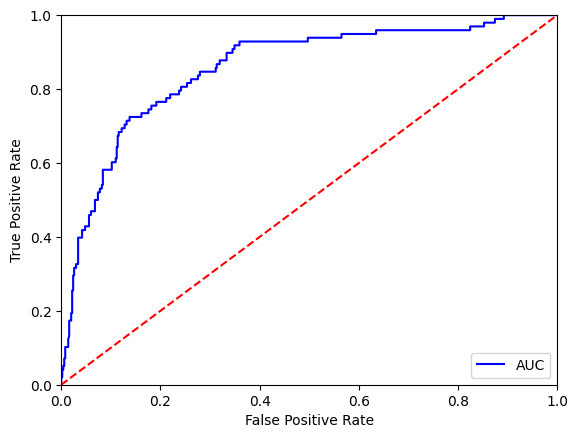

Accuracy for deepnn on Morgan Fingerprint: 0.8790849673202614
F1 for deepnn on Morgan Fingerprint: 0.5888888888888889
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.95472441 0.04527559]
 [0.49038462 0.50961538]]
 True Positive: 0.5096153846153846
 True Negative: 0.9547244094488189
False Positive: 0.045275590551181105
False Negative: 0.49038461538461536
Test ROC AUC (SR-MMP): 0.9026442307692307


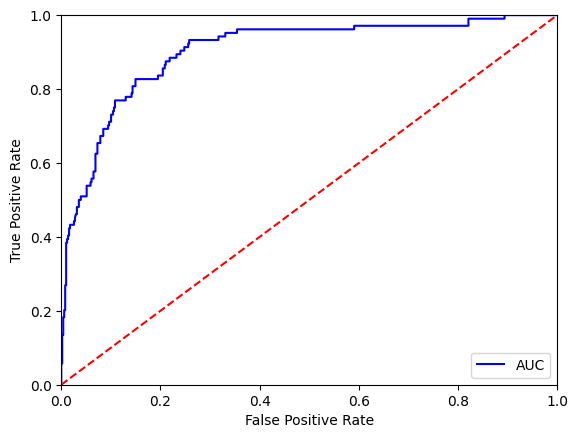

Accuracy for deepnn on Morgan Fingerprint: 0.9069767441860465
F1 for deepnn on Morgan Fingerprint: 0.5675675675675677
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.96517413 0.03482587]
 [0.50588235 0.49411765]]
 True Positive: 0.49411764705882355
 True Negative: 0.9651741293532339
False Positive: 0.03482587064676617
False Negative: 0.5058823529411764
Test ROC AUC (NR-AhR): 0.8908008974734172


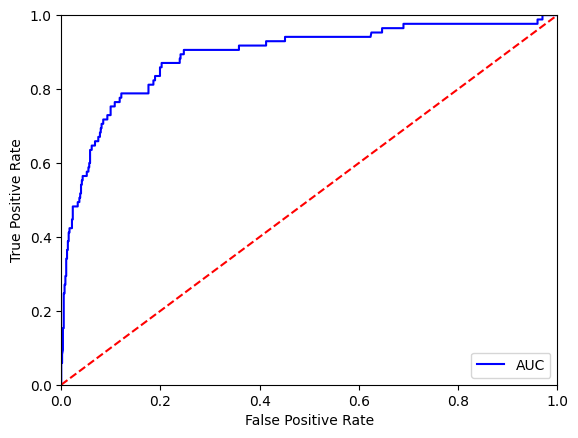

Accuracy for deepnn on Morgan Fingerprint: 0.9710743801652892
F1 for deepnn on Morgan Fingerprint: 0.5333333333333333
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.9971223  0.0028777 ]
 [0.61290323 0.38709677]]
 True Positive: 0.3870967741935484
 True Negative: 0.9971223021582734
False Positive: 0.0028776978417266188
False Negative: 0.6129032258064516
Test ROC AUC (NR-ER-LBD): 0.8091668600603388


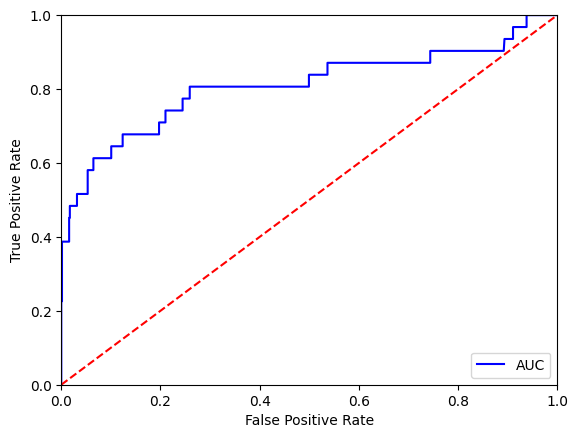

Accuracy for deepnn on Morgan Fingerprint: 0.9578231292517007
F1 for deepnn on Morgan Fingerprint: 0.2439024390243902
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.99148936 0.00851064]
 [0.83333333 0.16666667]]
 True Positive: 0.16666666666666666
 True Negative: 0.9914893617021276
False Positive: 0.00851063829787234
False Negative: 0.8333333333333334
Test ROC AUC (SR-ATAD5): 0.8901891252955083


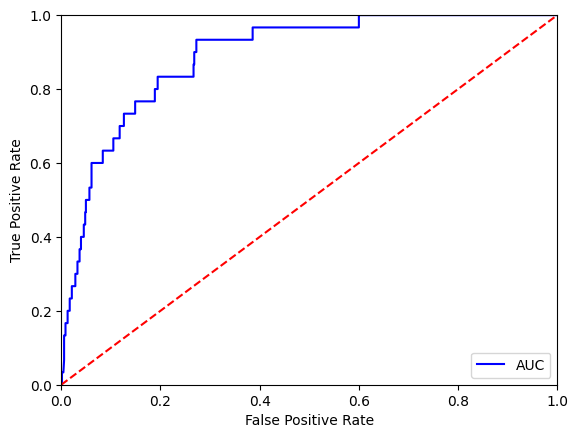

Accuracy for deepnn on Morgan Fingerprint: 0.9387464387464387
F1 for deepnn on Morgan Fingerprint: 0.21818181818181817
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.98939394 0.01060606]
 [0.85714286 0.14285714]]
 True Positive: 0.14285714285714285
 True Negative: 0.9893939393939394
False Positive: 0.010606060606060607
False Negative: 0.8571428571428571
Test ROC AUC (SR-p53): 0.866017316017316


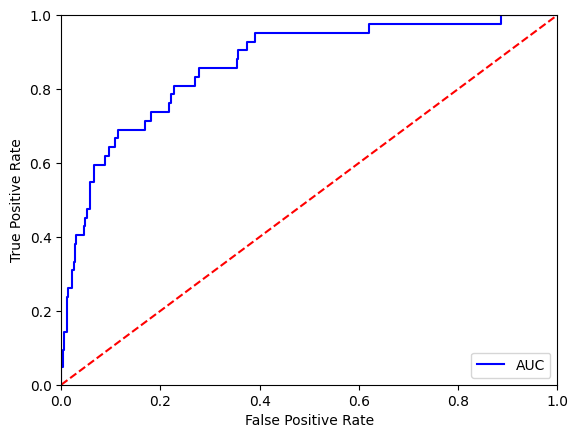

Accuracy for deepnn on Morgan Fingerprint: 0.959731543624161
F1 for deepnn on Morgan Fingerprint: 0.7272727272727273
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.97826087 0.02173913]
 [0.27272727 0.72727273]]
 True Positive: 0.7272727272727273
 True Negative: 0.9782608695652174
False Positive: 0.021739130434782608
False Negative: 0.2727272727272727
Test ROC AUC (CT_TOX): 0.9044795783926218


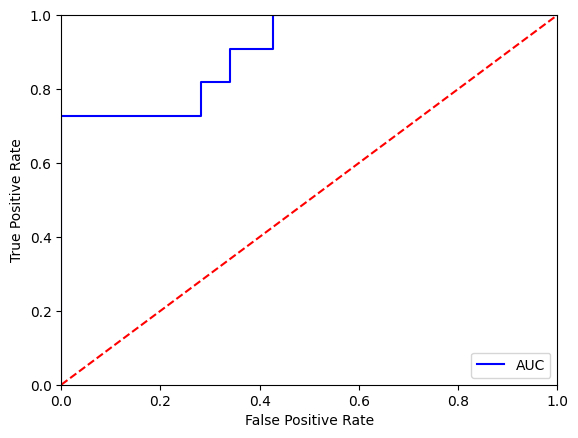

In [48]:
results_valid = {}
# Collects performance metrics for all tasks on Valid set
for i in range(len(all_tasks)):
    
    valid_datapoints = y_valid[:,i] >= 0
    y_valid_task = y_valid[valid_datapoints,i] 
    y_valid_pred_task = y_valid_pred[i].detach().numpy()[valid_datapoints,0]
    
    
    acc = accuracy_score(y_valid_task, np.round(y_valid_pred_task))
    print('Accuracy for deepnn on Morgan Fingerprint:', acc)
    
    bacc = sk.metrics.balanced_accuracy_score(y_valid_task, np.round(y_valid_pred_task))

    f1 = f1_score(y_valid_task, np.round(y_valid_pred_task), pos_label=1)
    print('F1 for deepnn on Morgan Fingerprint:', f1)

    cfm = sk.metrics.confusion_matrix(y_valid_task, np.round(y_valid_pred_task))
    cfm = cfm.astype('float') / cfm.sum(axis=1)[:, np.newaxis]

    print('Confusion Matrix for deepnn on Morgan Fingerprint:\n', cfm)

    tn, fp, fn, tp = cfm.ravel()
    pr = tp / (tp + fp)
    rc = tp / (tp + fn)
    print(' True Positive:', tp)
    print(' True Negative:', tn)
    print('False Positive:', fp)
    print('False Negative:', fn)
    
    
    auc = roc_auc_score(y_valid_task, y_valid_pred_task)
    print('Test ROC AUC ({}):'.format(all_tasks[i]), auc)
    
    results_valid[all_tasks[i]] = [auc, acc, bacc, tn, tp, pr, rc, f1]

    fpr, tpr, threshold = sk.metrics.roc_curve(y_valid_task, y_valid_pred_task)
    plt.plot(fpr, tpr, 'b', label = 'AUC')
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [49]:
print('Task'.ljust(10), '\t', '  AUC ', ' ACC ', ' BACC ', ' TN  ', ' TP  ', ' PR  ', ' RC  ', ' F1  ')
for task, auc in results_valid.items():
    print(task.ljust(10), '\t', np.round(auc,3))

Task       	   AUC   ACC   BACC   TN    TP    PR    RC    F1  
NR-AR      	 [0.755 0.975 0.678 0.999 0.357 0.996 0.357 0.513]
NR-Aromatase 	 [0.935 0.965 0.638 0.99  0.286 0.965 0.286 0.364]
NR-PPAR-gamma 	 [0.88  0.963 0.498 0.997 0.    0.    0.    0.   ]
SR-HSE     	 [0.859 0.947 0.563 0.998 0.128 0.988 0.128 0.222]
NR-AR-LBD  	 [0.911 0.976 0.672 0.997 0.348 0.992 0.348 0.485]
NR-ER      	 [0.767 0.903 0.629 0.989 0.269 0.962 0.269 0.4  ]
SR-ARE     	 [0.857 0.863 0.647 0.968 0.327 0.911 0.327 0.438]
SR-MMP     	 [0.903 0.879 0.732 0.955 0.51  0.918 0.51  0.589]
NR-AhR     	 [0.891 0.907 0.73  0.965 0.494 0.934 0.494 0.568]
NR-ER-LBD  	 [0.809 0.971 0.692 0.997 0.387 0.993 0.387 0.533]
SR-ATAD5   	 [0.89  0.958 0.579 0.991 0.167 0.951 0.167 0.244]
SR-p53     	 [0.866 0.939 0.566 0.989 0.143 0.931 0.143 0.218]
CT_TOX     	 [0.904 0.96  0.853 0.978 0.727 0.971 0.727 0.727]


In [50]:

# Save MTDNN results to CSV file for comparison MT vs ST (normalized confusion matrix values)
import pandas as pd

# Read existing CSV with ST results
csv_path = '../../../../results/mt_vs_st.csv'
results_df = pd.read_csv(csv_path)

# Update with MTDNN (MT) results - test set
for i in range(len(all_tasks)):
    valid_datapoints = y_test[:,i] >= 0
    y_test_task = y_test[valid_datapoints,i] 
    y_test_pred_task = y_test_pred[i].detach().numpy()[valid_datapoints,0]
    
    # Calculate confusion matrix (raw counts)
    cfm_raw = sk.metrics.confusion_matrix(y_test_task, np.round(y_test_pred_task))
    
    # Normalize by rows (same as in the evaluation section)
    cfm = cfm_raw.astype('float') / cfm_raw.sum(axis=1)[:, np.newaxis]
    tn, fp, fn, tp = cfm.ravel()
    
    # Update the row for this endpoint with MT values
    results_df.loc[results_df['ENDPOINT'] == all_tasks[i], 'TPMT'] = round(tp, 4)
    results_df.loc[results_df['ENDPOINT'] == all_tasks[i], 'TNMT'] = round(tn, 4)
    results_df.loc[results_df['ENDPOINT'] == all_tasks[i], 'FPMT'] = round(fp, 4)
    results_df.loc[results_df['ENDPOINT'] == all_tasks[i], 'FNMT'] = round(fn, 4)

# Save updated CSV
results_df.to_csv(csv_path, index=False)

print(f"✓ Results updated in {csv_path}")
print("\nComparison MT (ClinTox+Tox21) vs ST (Tox21):")
print(results_df)


✓ Results updated in ../../../../results/mt_vs_st.csv

Comparison MT (ClinTox+Tox21) vs ST (Tox21):
         ENDPOINT    TPMT    TNMT    FPMT    FNMT    TPST    TNST    FPST  \
0           NR-AR  0.3235  0.9986  0.0014  0.6765  0.4118  1.0000  0.0000   
1    NR-Aromatase  0.2432  0.9927  0.0073  0.7568  0.2973  0.9872  0.0128   
2   NR-PPAR-gamma  0.0625  0.9953  0.0047  0.9375  0.1875  0.9984  0.0016   
3          SR-HSE  0.1750  0.9967  0.0033  0.8250  0.2000  0.9951  0.0049   
4       NR-AR-LBD  0.3913  0.9955  0.0045  0.6087  0.5217  0.9955  0.0045   
5           NR-ER  0.2326  0.9891  0.0109  0.7674  0.2442  0.9872  0.0128   
6          SR-ARE  0.3222  0.9666  0.0334  0.6778  0.4667  0.9411  0.0589   
7          SR-MMP  0.5000  0.9559  0.0441  0.5000  0.5222  0.9643  0.0357   
8          NR-AhR  0.4366  0.9644  0.0356  0.5634  0.4225  0.9661  0.0339   
9       NR-ER-LBD  0.3056  0.9895  0.0105  0.6944  0.3333  0.9880  0.0120   
10       SR-ATAD5  0.1379  0.9942  0.0058  0.8621  0.